In [11]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", None)
REGION = "ap-southeast-2"

session = boto3.session.Session(region_name=REGION)
s3 = session.client("s3")

print("Ready.")

Ready.


In [12]:
BUCKET = "dcceew-eds-data"
PREFIX = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/"

def scan_tf_files(bucket, prefix):
    paginator = s3.get_paginator("list_objects_v2")
    records = []

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if not key.lower().endswith(".tif"):
                continue

            # Extract tile name from path
            # e.g. .../tiles/p089r078/something.tf
            parts = key[len(prefix):].split("/")
            tile = parts[0] if parts else "UNKNOWN"

            records.append({
                "tile": tile,
                "key": key,
                "size_bytes": int(obj["Size"])
            })

    return pd.DataFrame(records)

df = scan_tf_files(BUCKET, PREFIX)

print("Total .tf files:", len(df))
df.head()

Total .tf files: 1469


,tile,key,size_bytes
0,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/db8/L8/2023/20230306/lztmre_p089r078_20230306_db8_28356.tif,89932516
1,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/db8/L8/2025/20250701/lztmre_p089r078_20250701_db8_28356.tif,105828958
2,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/db8/L8/2025/20251208/lztmre_p089r078_20251208_db8_28356.tif,80195452
3,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/db8/L9/2023/20231024/lztmre_p089r078_20231024_db8_28356.tif,80066496
4,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/ndvi/L8/2013/20130427/lztmre_p089r078_20130427_ffmask_28356.tif,526383


In [13]:
summary = (
    df.groupby("tile")
      .agg(
          tf_count=("key", "count"),
          total_size_bytes=("size_bytes", "sum")
      )
      .sort_values("tf_count", ascending=False)
)

summary["total_size_mb"] = summary["total_size_bytes"] / (1024 * 1024)

summary.head(20)

,tf_count,total_size_bytes,total_size_mb
tile,,,
p089r078,476,7565544742,7215.065710
p089r079,392,15783125106,15051.961046
p089r080,358,23025618806,21958.941275
p089r081,243,15856639969,15122.070283


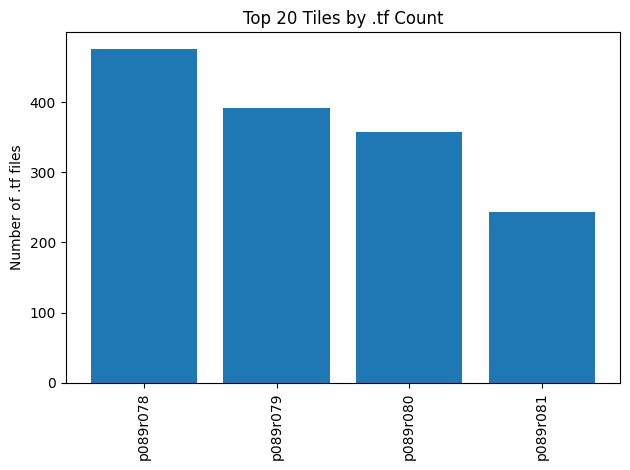

In [14]:
top_n = 20

summary_sorted = summary.sort_values("tf_count", ascending=False).head(top_n)

plt.figure()
plt.bar(summary_sorted.index, summary_sorted["tf_count"])
plt.xticks(rotation=90)
plt.ylabel("Number of .tf files")
plt.title(f"Top {top_n} Tiles by .tf Count")
plt.tight_layout()
plt.show()

In [15]:
def search_tiles(pattern):
    return summary.loc[summary.index.str.contains(pattern, case=False)]

search_tiles("p089")

,tf_count,total_size_bytes,total_size_mb
tile,,,
p089r078,476,7565544742,7215.065710
p089r079,392,15783125106,15051.961046
p089r080,358,23025618806,21958.941275
p089r081,243,15856639969,15122.070283


In [16]:
df[df["key"].str.contains("dll", case=False)].head(20)

,tile,key,size_bytes
469,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/lztmre_p089r078_d2023030620231024_vi-ndvi_dllmz_cog.tif,2175919
473,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2025070120260117/lztmre_p089r078_d2025070120251208_vi-ndvi_dllmz_cog.tif,2612315
865,p089r079,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r079/outputs/p089r079_d2025060720260125/lztmre_p089r079_d2025060720260109_vi-ndvi_dllmz_cog.tif,4503897
1223,p089r080,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r080/outputs/p089r080_d2025060720260125/lztmre_p089r080_d2025060720260109_vi-ndvi_dllmz_cog.tif,9687765


In [17]:
BUCKET = "dcceew-eds-data"
BASE_PREFIX = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/"

def scan_tile_outputs(bucket, base_prefix):
    paginator = s3.get_paginator("list_objects_v2")
    records = []

    for page in paginator.paginate(Bucket=bucket, Prefix=base_prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            # Only include outputs folders
            if "/outputs/" not in key:
                continue

            # Extract tile name
            # tiles/{tile}/outputs/...
            rel = key[len(base_prefix):]
            parts = rel.split("/")
            if len(parts) < 3:
                continue

            tile = parts[0]
            size = int(obj["Size"])

            records.append({
                "tile": tile,
                "key": key,
                "size_bytes": size,
                "extension": key.split(".")[-1].lower() if "." in key else "none"
            })

    return pd.DataFrame(records)


df_outputs = scan_tile_outputs(BUCKET, BASE_PREFIX)

print("Total output files:", len(df_outputs))
df_outputs.head()

Total output files: 90


,tile,key,size_bytes,extension
0,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/lztmre_p089r078_d2023030620231024_vi-ndvi_dljmz_cog.tif,11524617,tif
1,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/lztmre_p089r078_d2023030620231024_vi-ndvi_dllmz_cog.tif,2175919,tif
2,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/masks/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80_mask_cog.tif,513819,tif
3,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/masks/lztmre_p089r078_p089r078_d2023030620231024_strong_ge60_mask_cog.tif,608579,tif
4,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80.cpg,5,cpg


In [18]:
summary_outputs = (
    df_outputs
    .groupby("tile")
    .agg(
        file_count=("key", "count"),
        total_size_bytes=("size_bytes", "sum")
    )
    .sort_values("file_count", ascending=False)
)

summary_outputs["total_size_gb"] = summary_outputs["total_size_bytes"] / (1024**3)

summary_outputs.head(20)

,file_count,total_size_bytes,total_size_gb
tile,,,
p089r078,48,57249308,0.053318
p089r079,14,46106274,0.042940
p089r080,14,94308040,0.087831
p089r081,14,65065866,0.060597


In [19]:
# Get all tile folders
all_tiles = set()

paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=BUCKET, Prefix=BASE_PREFIX, Delimiter="/"):
    for cp in page.get("CommonPrefixes", []):
        tile = cp["Prefix"][len(BASE_PREFIX):].strip("/")
        all_tiles.add(tile)

tiles_with_outputs = set(summary_outputs.index)

missing_outputs = sorted(all_tiles - tiles_with_outputs)

print("Tiles with NO outputs folder:", len(missing_outputs))
missing_outputs[:20]

Tiles with NO outputs folder: 1


['p089r082']

In [20]:
type_summary = (
    df_outputs
    .groupby(["tile", "extension"])
    .size()
    .unstack(fill_value=0)
)

type_summary.head(10)

extension,cpg,dbf,prj,shp,shx,tif
tile,,,,,,
p089r078,8,8,8,8,8,8
p089r079,2,2,2,2,2,4
p089r080,2,2,2,2,2,4
p089r081,2,2,2,2,2,4


In [22]:
BUCKET = "dcceew-eds-data"
BASE = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/"

# Option A (preferred): NDVI stored under a known folder name
NDVI_SUBPATH = "/ndvi/"          # change if yours is different e.g. "/ndvi_tiles/" or "/inputs/ndvi/"

# Option B: NDVI identified by filename containing "ndvi"
NDVI_NAME_CONTAINS = "ndvi"      # set to None to disable

In [23]:
import pandas as pd

def count_ndvi_and_outputs(bucket: str, base_prefix: str, ndvi_subpath="/ndvi/", ndvi_name_contains="ndvi"):
    if base_prefix and not base_prefix.endswith("/"):
        base_prefix += "/"

    paginator = s3.get_paginator("list_objects_v2")

    # counts[tile] = dict(...)
    counts = {}

    for page in paginator.paginate(Bucket=bucket, Prefix=base_prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            size = int(obj["Size"])

            # skip folder markers
            if key.endswith("/") and size == 0:
                continue

            rel = key[len(base_prefix):]
            parts = rel.split("/")
            if len(parts) < 2:
                continue

            tile = parts[0]

            d = counts.setdefault(tile, {
                "tile": tile,
                "ndvi_files": 0,
                "ndvi_bytes": 0,
                "result_files": 0,
                "result_bytes": 0,
                "total_files": 0,
                "total_bytes": 0,
            })

            d["total_files"] += 1
            d["total_bytes"] += size

            # "results" == anything under outputs/
            if f"/{tile}/outputs/" in key:
                d["result_files"] += 1
                d["result_bytes"] += size

            # NDVI match:
            ndvi_hit = False

            # Folder-based
            if ndvi_subpath and f"/{tile}{ndvi_subpath}" in key:
                ndvi_hit = True

            # Name-based (fallback)
            if (not ndvi_hit) and ndvi_name_contains:
                if ndvi_name_contains.lower() in key.lower():
                    # but avoid counting results that merely mention NDVI in filenames if you don't want that:
                    # comment out next 2 lines if you *do* want outputs ndvi included
                    if f"/{tile}/outputs/" not in key:
                        ndvi_hit = True

            if ndvi_hit:
                d["ndvi_files"] += 1
                d["ndvi_bytes"] += size

    df = pd.DataFrame(counts.values()).sort_values("tile")
    for col in ["ndvi_bytes", "result_bytes", "total_bytes"]:
        df[col.replace("bytes", "gb")] = df[col] / (1024**3)
    return df

df_counts = count_ndvi_and_outputs(
    BUCKET,
    BASE,
    ndvi_subpath=NDVI_SUBPATH,
    ndvi_name_contains=NDVI_NAME_CONTAINS
)

df_counts.head(20)

,tile,ndvi_files,ndvi_bytes,result_files,result_bytes,total_files,total_bytes,ndvi_gb,result_gb,total_gb
0,p089r078,464,7180087904,48,57249308,516,7593360634,6.686978,0.053318,7.071868
1,p089r079,386,15326593014,14,46106274,402,15794876014,14.274002,0.042940,14.710125
2,p089r080,352,22297548836,14,94308040,368,23061846860,20.766211,0.087831,21.478019
3,p089r081,264,16570428506,14,65065866,280,17432486208,15.432414,0.060597,16.235268
4,p089r082,234,13924079910,14,82522806,250,14776447888,12.967810,0.076855,13.761639
5,p089r083,19,713681963,0,0,21,1193097537,0.664668,0.000000,1.111159


In [24]:
df_counts.sort_values("ndvi_files", ascending=False).head(20)[
    ["tile", "ndvi_files", "ndvi_gb", "result_files", "result_gb"]
]

,tile,ndvi_files,ndvi_gb,result_files,result_gb
0,p089r078,464,6.686978,48,0.053318
1,p089r079,386,14.274002,14,0.042940
2,p089r080,352,20.766211,14,0.087831
3,p089r081,264,15.432414,14,0.060597
4,p089r082,234,12.967810,14,0.076855
5,p089r083,19,0.664668,0,0.000000


In [25]:
df_counts[df_counts["ndvi_files"] == 0][["tile", "result_files", "result_gb"]].head(50)

,tile,result_files,result_gb


In [26]:
df_counts[df_counts["result_files"] == 0][["tile", "ndvi_files", "ndvi_gb"]].head(50)

,tile,ndvi_files,ndvi_gb
5,p089r083,19,0.664668


In [27]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df_outputs[df_outputs["tile"] == "p089r078"]

,tile,key,size_bytes,extension
0,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/lztmre_p089r078_d2023030620231024_vi-ndvi_dljmz_cog.tif,11524617,tif
1,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/lztmre_p089r078_d2023030620231024_vi-ndvi_dllmz_cog.tif,2175919,tif
2,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/masks/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80_mask_cog.tif,513819,tif
3,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/masks/lztmre_p089r078_p089r078_d2023030620231024_strong_ge60_mask_cog.tif,608579,tif
4,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80.cpg,5,cpg
5,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80.dbf,25382,dbf
6,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80.prj,408,prj
7,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80.shp,1668996,shp
8,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2023030620231024_clear_ge80.shx,4804,shx
9,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/outputs/p089r078_d2023030620231024/vectors/clear_ge80/lztmre_p089r078_p089r078_d2025070120260117_clear_ge80.cpg,5,cpg
